In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy import sparse
import time
import math
from numba import njit,jit,prange,cuda
import cmath

# Recommendation System with Collaborative Filtering

## Mục lục
* [Danh sách thành viên](#c1)
* [Link github](#c2)
* [Danh sách các phiên bản](#c3)
* [Định nghĩa](#c3)
* [Các bước thực hiện](#c4)
    * [Tạo ma trận user-item (Utility Matrix)](#c41)
    * [Normalize ma trận Utility Matrix ](#c41)
    * [Tính toán Cosine Similarity giữ các user](#c42)
    * [Caculate rating](#c42)
    * [Denormalize  ma trận Utility Matrix](#c42)
    * [Demo recommend](#c43)   
    * [Đánh giá mức độ chính xác](#c44)      
* [Thống kê thời gian giữa các phiên bản](#c6)
* [Conclusion](#c7)
* [References](#c8)

## Danh sách thành viên <a name="c1"></a>

|ID | MSSV     | Họ tên             |Đóng góp công việc|
|---|----------|--------------------|-----|
|1|20127411|Đỗ Đạt Thành| • Đóng góp ý kiến cho ý tưởng ban đầu  <br>• Triển khai hàm “cosine similarity” các phiên bản tuần tự và song song hóa <br>• Triển khai hàm “recommend”<br>• Hỗ trợ phát triển hàm “normalize” phiên bản song song hóa <br>• Hỗ trợ phát triển hàm “predict” phiên bản song song hóa <br>• Soạn slide và đóng góp nội dung file tổng hợp
|2|20127449|Trần Quốc Bảo|• Đóng góp ý kiến cho ý tưởng ban đầu  <br>• Chuẩn bị input datasets <br>• Triển khai hàm “normalize”  các phiên bản tuần tự và song song hóa <br>• Triển khai hàm “predict” các phiên bản tuần tự và song song hóa <br>• Đánh giá tốc độ và độ chính xác các phiên bản <br>• Chỉnh lý nội dung file tổng hợp


##  Link Github <a name="c2"></a>
- https://github.com/datthanh1942/Parallel_Programming

## Danh sách các phiên bản <a name="c3"></a>

- `CPU version 1`:  code tuần tự không xài thư viện
- `CPU version 2`:  code tuần tự xài thư viện
- `CPU verion 3`: code song song trên CPU xài numba jit
- `GPU version 1`:  song song GPU
- `GPU version 2`:  song song GPU (share Memory)

## Định nghĩa <a name="c3"></a>

**Collaborative Filtering** là một kỹ thuật có thể lọc ra các mục mà người dùng có thể thích trên cơ sở phản ứng của những người dùng tương tự. Cách hoạt động bằng cách tìm kiếm một nhóm lớn người và tìm một nhóm người dùng nhỏ hơn có sở thích tương tự như một người dùng cụ thể, xem xét các mục họ thích và kết hợp chúng để tạo danh sách đề xuất được xếp hạng.

Đơn vị tính cũng như đề xuất xếp hạng chủ yếu sẽ dựa vào các trọng số tương quan giữa các tập user với nhau. Nhiệm vụ đầu tiên của chúng ta đó chính là tính toán được những trọng số tương quan đó để có thể dự đoán các đề xuất liên quan cho người dùng.

## Các bước thực hiện <a name="c4"></a>

### Bước 1: Tạo ma trận user-item <a name="c41"></a>

In [5]:
df_movie_100k=pd.read_csv('/content/drive/MyDrive/ml-100k/ml-100k/u.data',delimiter='\t', header=None,
                      names=['userId', 'movieId', 'rating', 'timestamp'])
Utility_Maxtrix=df_movie_100k.pivot_table(index='movieId',columns='userId',values='rating')
# Utility_Maxtrix_train_100k=train_data.pivot_table(index='movieId',columns='userId',values='rating')
Movie_index=Utility_Maxtrix.index
User_index=Utility_Maxtrix.columns
Utility_Maxtrix_100k=np.array(Utility_Maxtrix)

### Bước 2: Normalize ma trận Utility matrix <a name="c42"></a>

- Việc normalize data sẽ giúp ta xác định được đâu là item mà user thích ( tương ứng với  giá trị dương), item mà user không thích ( tương ứng với giá trị âm) và cuối cùng lf những item mà user chưa rate (tương ứng với gia trị là 0)
- Input: Ma trận Utility
- Output: Ma trận sau khi được normalize

##### Code tuần tự CPU  version 1 (không sài thư viện)

In [6]:
def  Normalized_matrix_CPU_ver1(arr):
    arr_temp=arr.copy()
    num_cols = len(arr_temp[0])
    avg_columns = [0] * num_cols
    count_columns = [0] * num_cols

    for row in arr_temp:
        for j in range(num_cols):
            if np.isnan(row[j]) ==False:
                avg_columns[j] += row[j]
                count_columns[j] += 1

    for j in range(num_cols):
         avg_columns[j] /= count_columns[j]

    for i in range(len(arr_temp)):
        for j in range(len(arr_temp[0])):
            if np.isnan(arr_temp[i][j]):
                arr_temp[i][j]=0
            else:
                arr_temp[i][j] -= avg_columns[j]
    return  arr_temp,avg_columns

In [ ]:
Normalize_data_CPU_ver1,Avg_column_CPU_ver1=Normalized_matrix_CPU_ver1(Utility_Maxtrix_100k)

##### Code tuần tự CPU  version 2 (sài thư viện numpy)

- Với hàm sài thư viện numpy, hàm normalize có thể được tối ưu ở phần tính giá
 trung bình trị rating của mỗi user

In [8]:
def Normalized_matrix_CPU_ver2(arr):

    arr_temp = arr.copy()

    num_rows, num_cols = arr_temp.shape

    avg_columns = np.nanmean(arr_temp, axis=0)

    for i in range(num_rows):
        for j in range(num_cols):
            if np.isnan(arr_temp[i, j]):
                arr_temp[i, j] = 0
            else:
                arr_temp[i, j] -= avg_columns[j]

    return arr_temp, avg_columns

In [ ]:
Normalize_data_CPU_ver2,Avg_column_CPU_ver2=Normalized_matrix_CPU_ver2(Utility_Maxtrix_100k)

- So sánh kết quả CPU version 1 và CPU version 2

In [10]:
np.mean(np.abs(Normalize_data_CPU_ver1-Normalize_data_CPU_ver2))

0.0

##### Song Song CPU

- Phiên bản này chỉ sử dụng jit và prange của thư viện numba để song song hóa trên CPU

In [11]:
@jit(nopython=True, parallel=True)
def Normalized_matrix_jit(arr):
    arr_temp = arr.copy()
    num_rows = arr_temp.shape[0]
    num_cols = arr_temp.shape[1]


    avg_columns = np.zeros(num_cols)
    count_columns = np.zeros(num_cols, dtype=np.int32)

    for i in prange(num_rows): ### Mỗi dòng sẽ là độc lập với nhau
        for j in range(num_cols):
            if  np.isnan(arr_temp[i, j])== False:
                avg_columns[j] += arr_temp[i, j]
                count_columns[j] += 1

    avg_columns=avg_columns/count_columns

    for i in prange(num_rows): ## Mỗi dòng sẽ độc lập với nhau
        for j in range(num_cols):
            if np.isnan(arr_temp[i, j]):
                arr_temp[i, j] = 0
            else:
                arr_temp[i, j] -= avg_columns[j]
    return arr_temp, avg_columns

In [ ]:
Normalize_data_jit,Avg_column_jit=Normalized_matrix_jit(Utility_Maxtrix_100k)

- So sánh kết quả CPU version 1 và song song trên CPU

In [13]:
np.mean(np.abs(Normalize_data_CPU_ver1-Normalize_data_jit))

1.5293231624491398e-05

#####  Song Song trên GPU



  - Khởi tạo mảng `column_sums` , `column_counts` có giá trị bằng 0
  - Copy dữ liệu `arr`, `column_sums`,`column_counts` từ CPU host sang bộ nhớ của GPU/device
  - Cấp phát vùng nhớ cho ma trận kết quả `Normalized_Matrix `
  - Xác định số thread trên mỗi block (16,32) Max thread: 512
    - số thread trên mỗi block `threadsperblock` là thread block 2 chiều với chiều x là 16 thread và y là 32 thread
    - Ta chia block cho mỗi grid bằng công thức:
    1. blockspergrid_x = (số cột của Utility Matrix + 16 - 1) / 32 (16 là chiều x của thread)
    2. blockspergrid_y = (số dòng của Utility Matrix + 32 - 1) / 32 (32 là chiều y của thread)
    - Từ đó ta có kích thước của grid bằng (blockspergrid_x, blockspergrid_y)

  - Gọi hàm `compute_column_sums` (@cuda.jit)(hàm sẽ tính tổng  và các giá trị rating đếm các giá trị rating khác nan của 1 user )
    - Mỗi thread kiểm tra 1 giá trị trong mảng nếu khác nan thì cộng giá trị đó  vào mảng `column_sums` theo index col, tương tự cộng 1 vào mảng `column_counts` ở index col
  - Copy `column_sums` ,`column_counts` từ GPU/device về CPU/host
  - Tính trung bình của từng cột và gán vào mảng kết quả `avg_columns`
  - Copy `avg_columns` từ CPU/host sang bộ nhớ GPU/device
  - Gọi hàm `Normalized_Matrix_kernel` (@cuda.jit)
    - Mỗi thread kiểm tra giá trị nếu khác nan thì trừ giá trị đó cho `avg_column` và gán vào mảng kết quả, ngược lại thì gán vào mảng kết quả giá trị 0
  - Sao chép mảng kết quả `Normalized_Matrix` về CPU/host và return

In [14]:
@cuda.jit
def compute_column_sums(arr, column_sums, column_counts):
    col, row = cuda.grid(2)
    if row < arr.shape[0] and col < arr.shape[1]:
        value = arr[row, col]
        if math.isnan(value)==False:
            cuda.atomic.add(column_sums, col, value)
            cuda.atomic.add(column_counts, col, 1)

# Hàm kernel chuẩn hóa ma trận
@cuda.jit
def Normalized_Matrix_kernel(arr,avg_columns,result):
    col, row = cuda.grid(2)
    if row < arr.shape[0] and col < arr.shape[1]:
        value = arr[row, col]
        if math.isnan(value):
            result[row, col] = 0
        else:
            result[row, col]= arr[row, col] - avg_columns[col]

def Normalize_matrix_GPU(arr):

    num_rows, num_cols = arr.shape

    # Khởi tạo mảng tổng và đếm cho mỗi cột
    column_sums = np.zeros(num_cols, dtype=np.float64)
    column_counts = np.zeros(num_cols, dtype=np.int32)

    # Cấp phát bộ nhớ trên GPU

    d_arr = cuda.to_device(arr)
    d_column_sums = cuda.to_device(column_sums)
    d_column_counts = cuda.to_device(column_counts)
    Normalized_Matrix = cuda.device_array((d_arr.shape[0], d_arr.shape[1]), dtype=np.float64)
    # Xác định kích thước block và grid
    threads_per_block=(16,32)
    blocks_per_grid_x = (num_cols+ threads_per_block[0] - 1) // threads_per_block[0]
    blocks_per_grid_y = (num_rows  + threads_per_block[1] - 1) // threads_per_block[1]
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # Gọi kernel tính tổng và đếm số phần tử
    compute_column_sums[blocks_per_grid, threads_per_block](d_arr, d_column_sums, d_column_counts)

    # Copy kết quả từ GPU về CPU
    column_sums = d_column_sums.copy_to_host()
    column_counts = d_column_counts.copy_to_host()

    # Tính giá trị trung bình của mỗi cột
    avg_columns = column_sums / column_counts

    # Copy giá trị trung bình lên GPU
    d_avg_columns = cuda.to_device(avg_columns)

    # Gọi kernel chuẩn hóa ma trận
    Normalized_Matrix_kernel[blocks_per_grid, threads_per_block](d_arr, d_avg_columns,Normalized_Matrix)

    # Copy ma trận đã chuẩn hóa về CPU
    arr_temp = Normalized_Matrix.copy_to_host()


    return arr_temp, avg_columns

In [ ]:
Normalize_data_GPU,Avg_column_GPU=Normalize_matrix_GPU(Utility_Maxtrix_100k)

- So sánh kết quả CPU version 1 và song song trên GPU

In [16]:
np.mean(np.abs(Normalize_data_CPU_ver1-Normalize_data_GPU))

0.0

### Bước 3: Tính toán cosine Similarity giữa các user <a name="c42"></a>

- Input: Ma trận Utility sau khi được normalize
- Output: Ma trận similarity giữa các user

#####  Phiên bản tuần tự CPU version 1 (không sài thư viện)

In [17]:
def cosine_similarity_CPU_ver1(matrix):
    n_cols = matrix.shape[1]
    result = np.zeros((n_cols, n_cols), dtype=np.float64)

    for r in range(n_cols):
        for c in range(r, n_cols):
            num = 0.0
            denom_a = 0.0
            denom_b = 0.0

            for k in range(matrix.shape[0]):
                num += matrix[k, r] * matrix[k, c]
                denom_a += matrix[k, r] ** 2
                denom_b += matrix[k, c] ** 2

            denom_a = np.sqrt(denom_a)
            denom_b = np.sqrt(denom_b)

            if denom_a != 0 and denom_b != 0:
                result[r, c] = num / (denom_a * denom_b)
            else:
                result[r, c] = 0.0

            # Đảm bảo tính đối xứng
            result[c, r] = result[r, c]

    return result

In [ ]:
cosine_similarity_Matrix_CPU_ver1=cosine_similarity_CPU_ver1(Normalize_data_CPU_ver1)

#####  Phiên bản tuần tự CPU version 2 (sài thư viện)

In [19]:
def cosine_similarity_CPU_ver2(sparse_matrix):
    # Transpose the matrix to compute cosine similarity between columns
    sparse_matrix_transposed = sparse_matrix.transpose()

    # Calculate cosine similarity (this will be a dense matrix)
    cosine_sim_matrix_dense = cosine_similarity(sparse_matrix_transposed)

    return cosine_sim_matrix_dense

In [ ]:
cosine_similarity_Matrix_CPU_ver2=cosine_similarity_CPU_ver2(Normalize_data_CPU_ver1)

- So sánh kết quả phiên bản tuần tự CPU version 1 và phiên bản tuần tự CPU  version 2 (sài thư viện)

In [21]:
np.mean(np.abs(cosine_similarity_Matrix_CPU_ver1-cosine_similarity_Matrix_CPU_ver2))

1.243560779570421e-17

#####  Phiên bản song song CPU

In [22]:
@jit(nopython=True, parallel = True)
def cosine_similarity_jit(matrix):
    n_cols = matrix.shape[1]
    result = np.zeros((n_cols, n_cols), dtype=np.float64)

    for r in prange(n_cols):
        for c in range(r, n_cols):
            num = 0.0
            denom_a = 0.0
            denom_b = 0.0

            for k in prange(matrix.shape[0]):
                num += matrix[k, r] * matrix[k, c]
                denom_a += matrix[k, r] ** 2
                denom_b += matrix[k, c] ** 2

            denom_a = np.sqrt(denom_a)
            denom_b = np.sqrt(denom_b)

            if denom_a != 0 and denom_b != 0:
                result[r, c] = num / (denom_a * denom_b)
            else:
                result[r, c] = 0.0

            # Đảm bảo tính đối xứng
            result[c, r] = result[r, c]

    return result

In [ ]:
cosine_similarity_Matrix_jit=cosine_similarity_jit(Normalize_data_CPU_ver1)


- So sánh phiên bản tuần tự CPU version 2 (sài thư viện) với phiên bản song song trên CPU

In [24]:
np.mean(np.abs(cosine_similarity_Matrix_CPU_ver2-cosine_similarity_Matrix_jit))

1.243560779570421e-17

#####  Phiên bản song song GPU version 1

In [25]:
@cuda.jit
def cosine_similarity_kernel_ver1(matrix, result):
    r, c = cuda.grid(2)
    if r < result.shape[0] and c < result.shape[1]:
        num = 0.0
        denom_a = 0.0
        denom_b = 0.0

        for k in range(matrix.shape[0]):
            num += matrix[k, r] * matrix[k, c]
            denom_a += matrix[k, r] ** 2
            denom_b += matrix[k, c] ** 2

        denom_a = math.sqrt(denom_a)
        denom_b = math.sqrt(denom_b)

        if denom_a != 0 and denom_b != 0:
            result[r, c] = num / (denom_a * denom_b)
        else:
            result[r, c] = 0.0

# Function to calculate cosine similarity using CUDA
def cosine_similarity_cuda_ver1(dense_matrix):
    n_cols = dense_matrix.shape[1]
    result = np.zeros((n_cols, n_cols), dtype=np.float64)

    # Configure the blocks and grids
    threadsperblock = (32, 32)
    blockspergrid_x = (result.shape[0] + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (result.shape[0] + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    # Allocate memory on the device
    d_matrix = cuda.to_device(dense_matrix)
    d_result = cuda.device_array_like(result)

    # Launch the kernel
    cosine_similarity_kernel_ver1[blockspergrid, threadsperblock](d_matrix, d_result)

    # Copy the result back to host
    d_result.copy_to_host(result)

    return result

In [ ]:
cosine_similarity_Matrix_cuda_ver1=cosine_similarity_cuda_ver1(Normalize_data_CPU_ver1)

- So sánh kết quả giữa phiên bản tuần tự CPU version 2(sài thư viện) với phiên bản song song trên GPU version 1

In [27]:
np.mean(np.abs(cosine_similarity_Matrix_CPU_ver2-cosine_similarity_Matrix_cuda_ver1))

1.421522746727078e-17

#####  Phiên bản song song GPU version 2 (Share Memory)

In [28]:
@cuda.jit
def cosine_similarity_kernel_ver2(matrix, result):
    # Khai báo shared memory cho block
    shared_result = cuda.shared.array(shape=(32, 32), dtype=np.float64)  # Size với block 32x32

    r, c = cuda.grid(2)
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    if r < matrix.shape[0] and c < matrix.shape[1] and r <= c:  # Chỉ xử lý khi r <= c
        num = 0.0
        denom_a = 0.0
        denom_b = 0.0

        for k in range(matrix.shape[0]):
            num += matrix[k, r] * matrix[k, c]
            denom_a += matrix[k, r] ** 2
            denom_b += matrix[k, c] ** 2

        denom_a = math.sqrt(denom_a)
        denom_b = math.sqrt(denom_b)

        if denom_a != 0 and denom_b != 0:
            shared_result[tx, ty] = num / (denom_a * denom_b)
        else:
            shared_result[tx, ty] = 0.0

        # Đồng bộ hóa tất cả các threads trong block
        cuda.syncthreads()

        # Gán kết quả từ shared memory ra global memory
        result[r, c] = shared_result[tx, ty]

        # Gán giá trị đối xứng
        if r != c: # Tránh gán đè giá trị đã tính
            result[c, r] = shared_result[tx, ty]

# Function to calculate cosine similarity using CUDA
def cosine_similarity_cuda_ver2(dense_matrix):
    n_cols = dense_matrix.shape[1]
    result = np.zeros((n_cols, n_cols), dtype=np.float64)

    # Configure the blocks and grids
    threadsperblock = (32, 32)
    blockspergrid_x = (result.shape[0] + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (result.shape[0] + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    # Allocate memory on the device
    d_matrix = cuda.to_device(dense_matrix)
    d_result = cuda.device_array_like(result)

    # Launch the kernel
    cosine_similarity_kernel_ver2[blockspergrid, threadsperblock](d_matrix, d_result)

    # Copy the result back to host
    d_result.copy_to_host(result)

    return result

In [ ]:
cosine_similarity_Matrix_cuda_ver2=cosine_similarity_cuda_ver2(Normalize_data_CPU_ver1)

- So sánh kết quả phiên bản tuần tự CPU version 2 (sài thư viện) với phiên bản song song GPU version 2

In [30]:
np.mean(np.abs(cosine_similarity_Matrix_CPU_ver2-cosine_similarity_Matrix_cuda_ver2))

1.421522746727078e-17

### Bước 4: Caculate rating <a name="c42"></a>

- Input: Ma trận Utility sau khi được Normalize, Ma trận Similarity giữa các user, số nearest neighbors
- Output: Ma trận đã được dự đoán rating

#####  Phiên bản tuần tự CPU version 1 (Không sài thư viện)

In [31]:
def Find_user_rate_item_CPU_ver1(arr): ## tìm các user đã rated cho item đó
    KQ=[]
    for i in range(len(arr)):
        if arr[i]!=0:
            KQ.append(i)
    return KQ

def Find_max_user_similarity_CPU_ver1(arr,k,index): # tìm  k user có similairty giống vs user cần tìm nhất
    KQ=[]
    if len(index) <=k:
        KQ=index
    else:
        for i in range(k): # tim k then lon nhat
            max=arr[index[0]]
            max_index=index[0]
            for i in index[1:]:
                if arr[i] > max:
                    max =arr[i]
                    max_index=i
            KQ.append(max_index)
            index.remove(max_index)
    return KQ

def Predict_rating_CPU_ver1(arr,User_similarity,k):
    Matrix=arr.copy()
    KQ=arr.copy()
    for i in range(len(Matrix)):
        for j in range(len(Matrix[0])):
            if Matrix[i][j]==0:
                tu=0
                mau=1e-8
                user_rate_item=Find_user_rate_item_CPU_ver1(KQ[i])
                user_max_similarrity=Find_max_user_similarity_CPU_ver1(User_similarity[j],k,user_rate_item)
                for l in user_max_similarrity:
                    tu=tu+(Matrix[i][l]*User_similarity[j][l])
                    mau=mau+np.abs(User_similarity[j][l])
                Matrix[i][j]=(tu/mau)
    return Matrix

In [ ]:
find_rating_CPU_ver1=Predict_rating_CPU_ver1(Normalize_data_CPU_ver1,cosine_similarity_Matrix_CPU_ver2,2)

#####  Phiên bản tuần tự CPU version 2 (sài thư viện)

In [33]:

def find_user_rate_item_CPU_ver2(arr):
    # Trả về danh sách các chỉ số mà giá trị không bằng 0
    return np.where(arr != 0)[0]


def find_max_user_similarity_CPU_ver2(arr, k, index):
    arr = np.array(arr)
    index = np.array(index)

    if len(index) <= k:
        return index.tolist()
    else:
        # Get the indices of the k largest values in arr[index]
        sorted_indices = np.argsort(-arr[index])[:k]
        KQ = index[sorted_indices]
        return KQ.tolist()

def Predict_rating_CPU_ver2(arr,User_similarity,k):
    Matrix=arr.copy()
    KQ=arr.copy()
    for i in range(len(Matrix)):
        for j in range(len(Matrix[0])):
            if Matrix[i][j]==0:
                tu=0
                mau=1e-8
                user_rate_item=find_user_rate_item_CPU_ver2(KQ[i])
                user_max_similarrity=find_max_user_similarity_CPU_ver2(User_similarity[j],k,user_rate_item)
                for l in user_max_similarrity:
                    tu=tu+(Matrix[i][l]*User_similarity[j][l])
                    mau=mau+np.abs(User_similarity[j][l])
                Matrix[i][j]=(tu/mau)
    return Matrix

In [ ]:
find_rating_CPU_ver2=Predict_rating_CPU_ver2(Normalize_data_CPU_ver1,cosine_similarity_Matrix_CPU_ver2,2)

- So sánh kết quả phiên bản tuần tự CPU version 1 và phiên bản tuần tự CPU version 2

In [35]:
np.mean(np.abs(find_rating_CPU_ver1-find_rating_CPU_ver2))

0.0

#####  Phiên bản song song trên CPU

In [36]:

@jit(nopython=True)
def Find_user_rate_item_jit(arr):
    KQ = []
    for i in range(len(arr)):
        if arr[i] != 0:
            KQ.append(i)
    return KQ

@jit(nopython=True)
def Find_max_user_similarity_jit(arr, k, index):
    KQ = []
    if len(index) <= k:
        KQ = index
    else:
        for _ in range(k):  # find k largest elements
            max_val = arr[index[0]]
            max_index = index[0]
            for i in index[1:]:
                if arr[i] > max_val:
                    max_val = arr[i]
                    max_index = i
            KQ.append(max_index)
            index.remove(max_index)
    return KQ

@jit(nopython=True, parallel=True)
def Predict_rating_jit(arr, User_similarity, k):
    Matrix = arr.copy()
    Utility_arr=arr.copy()
    num_rows, num_cols = Matrix.shape
    for i in prange(num_rows):
        for j in prange(num_cols):
            if Matrix[i, j] == 0:
                tu = 0
                mau = 1e-8
                user_rate_item = Find_user_rate_item_jit(Utility_arr[i])
                user_max_similarity = Find_max_user_similarity_jit(User_similarity[j], k, user_rate_item)
                for l in user_max_similarity:
                    tu += Matrix[i, l] * User_similarity[j, l]
                    mau += abs(User_similarity[j, l])

                Matrix[i, j] = tu/mau

    return Matrix

In [37]:
start = time.time()
find_rating_jit=Predict_rating_jit(Normalize_data_CPU_ver1,cosine_similarity_Matrix_CPU_ver2,2)
end = time.time()
print(f'Processing time predict rating: {end - start} s')

Processing time predict rating: 4.947792053222656 s


- So sánh kết quả phiên bản tuần tự CPU version 1 và phiên bản song song trên CPU

In [38]:
np.mean(np.abs(find_rating_CPU_ver1-find_rating_jit))

0.0

#####  Phiên bản song song trên GPU version 1


-  Chuyển `arr`, `User Similarity` từ bộ nhớ CPU/host sang bộ nhớ  GPU/device
- Cấp phát bộ nhớ cho ma trận kết quả `Predict_rating_result`
- Xác định số thread trên mỗi block (16,32) Max thread: 512
    - số thread trên mỗi block `threadsperblock` là thread block 2 chiều với chiều x là 16 thread và y là 32 thread
    - Ta chia block cho mỗi grid bằng công thức:
    1. blockspergrid_x = (số cột của Utility Matrix + 16 - 1) / 32 (16 là chiều x của thread)
    2. blockspergrid_y = (số dòng của Utility Matrix + 32 - 1) / 32 (32 là chiều y của thread)
    - Từ đó ta có kích thước của grid bằng (blockspergrid_x, blockspergrid_y)
- Gọi hàm `Predict_rating_kernel` (@cuda.jit)
  - Mỗi thread sẽ kiểm tra nếu giá trị đó bằng 0 (chưa được dự đoán):
    - Tìm các user đã rate cho item đó
    - Tìm 2 user có Similarity cao nhất so với user    
    - Thực hiện tính toán theo công thức:

    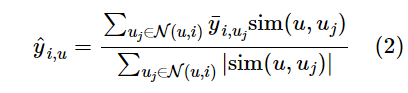
    - Gán kết quả đã tính vào ma trận kết quả
  - Copy kết quả về bộ nhớ CPU/host và return

In [39]:
import numpy as np
from numba import cuda, float32

@cuda.jit
def Predict_rating_cuda(Matrix, User_similarity, k, result):
    i, j = cuda.grid(2)
    if i < Matrix.shape[0] and j < Matrix.shape[1]:
        if Matrix[i, j] == 0:
            tu = 0.0
            mau = 1e-8

            user_rate_item = cuda.local.array((1000,), dtype=np.int32)
            user_rate_count = 0

            for idx in range(Matrix.shape[1]):
                if Matrix[i, idx] != 0:
                    user_rate_item[user_rate_count] = idx
                    user_rate_count += 1

            max_indices = cuda.local.array((16,), dtype=np.int32)

            for idx in range(min(k, user_rate_count)):
                max_value = -1.0
                max_index = -1
                cur_pos = 0
                for m in range(user_rate_count):
                    if User_similarity[j, user_rate_item[m]] > max_value:
                        max_value = User_similarity[j, user_rate_item[m]]
                        max_index = user_rate_item[m]
                        cur_pos = m

                if max_index != -1:
                    max_indices[idx] = max_index
                    user_rate_item[cur_pos] = -1  # Remove the used index

            for idx in range(min(k, user_rate_count)):
                max_index = max_indices[idx]
                if max_index != -1:
                    tu += Matrix[i, max_index] * User_similarity[j, max_index]
                    mau += abs(User_similarity[j, max_index])
            result[i, j] = tu / mau
        else:
            result[i, j] = Matrix[i, j]

def Predict_rating_GPU_ver1(arr, User_similarity, k):
    Matrix = arr.copy()
    #result = np.zeros_like(arr, dtype=np.float32)
    result = cuda.device_array((arr.shape[0], arr.shape[1]), dtype=np.float64)


    threadsperblock = (16, 32)
    blockspergrid_x = (result.shape[0] + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (result.shape[1] + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    Predict_rating_cuda[blockspergrid, threadsperblock](Matrix, User_similarity, k, result)

    result = result.copy_to_host()

    return result

In [ ]:
find_rating_GPU_ver1=Predict_rating_GPU_ver1(Normalize_data_CPU_ver1,cosine_similarity_Matrix_CPU_ver2,2)

- So sánh kết quả phiên bản tuần tự trên CPU version 1 và phiên bản song song trên GPU version 1

In [41]:
np.mean(np.abs(find_rating_CPU_ver1-find_rating_GPU_ver1))

0.05037996895568419

### Bước 5: Denormalize ma trận Utility matrix <a name="c42"></a>

- Input: Ma trận sau khi đã được dự đoán rating, ma trận giá trị trung bình của các user
- Output: Ma trận sau khi được denormalize lại giá trị rating ban đầu

#####  Phiên bản tuần tự CPU version 1 (Không sài thư viện)

In [42]:
def Denormalize_data_CPU_ver1(User_Avg,arr):
    KQ=arr.copy()
    for i in range(len(KQ)):
            for j in range(len(KQ[0])):
                KQ[i][j]= KQ[i][j] + User_Avg[j]
    return KQ

In [ ]:
Denormalize_matrix_CPU_ver1=Denormalize_data_CPU_ver1(Avg_column_CPU_ver1,find_rating_CPU_ver1)

#####  Phiên bản tuần tự CPU version 2 (sài thư viện)

In [44]:
def Denormalize_data_CPU_ver2(user_avg, arr):
    # Cộng user_avg vào mỗi hàng của ma trận arr
    KQ = arr + user_avg[np.newaxis, :]

    # Làm tròn kết quả đến 2 chữ số thập phân
    return KQ

In [ ]:
Denormalize_matrix_CPU_ver2=Denormalize_data_CPU_ver1(Avg_column_CPU_ver1,find_rating_CPU_ver1)

- So sánh kết quả phiên bản tuần tự CPU version 2 và phiên bản tuần tự CPU version 1

In [46]:
np.mean(np.abs(Denormalize_matrix_CPU_ver1-Denormalize_matrix_CPU_ver2))

0.0

#####  Phiên bản song song trên CPU

In [47]:
@jit(nopython=True, parallel=True)
def Denormalize_Matrix_jit(User_Avg,arr):
    KQ=arr.copy()
    for i in prange(len(KQ)):
            for j in range(len(KQ[0])):
                KQ[i][j]= KQ[i][j] + User_Avg[j]
    return KQ

In [ ]:
Denormalize_matrix_jit=Denormalize_Matrix_jit(Avg_column_CPU_ver1,find_rating_CPU_ver1)

- So sánh kết quả phiên bản song song trên CPU và phiên bản tuần tự CPU version 1

In [49]:
np.mean(np.abs(Denormalize_matrix_CPU_ver1-Denormalize_matrix_jit))

0.0

#####  Phiên bản song song trên GPU version 1

#### Denomalize Data
- Copy dữ liệu `arr`,`Avg_column` từ CPU/host lên bộ nhớ GPU/device
- Cấp phát bộ nhớ cho mảng kết quả `denormalize_matrix`
- Xác định số thread trên mỗi block (16,32) Max thread: 512
    - số thread trên mỗi block `threadsperblock` là thread block 2 chiều với chiều x là 16 thread và y là 32 thread
    - Ta chia block cho mỗi grid bằng công thức:
    1. blockspergrid_x = (số cột của Utility Matrix + 16 - 1) / 32 (16 là chiều x của thread)
    2. blockspergrid_y = (số dòng của Utility Matrix + 32 - 1) / 32 (32 là chiều y của thread)
    - Từ đó ta có kích thước của grid bằng (blockspergrid_x, blockspergrid_y)
- Gọi hàm `Denormalize_Matrix_Kernel` (@cuda.jit)
  - Mỗi thread song song thực hiện cộng  với giá trị trung bình của cột và lưu ra ma trận kết quả
- Copy ma trận kết quả từ GPU/device từ CPU/host và return

In [50]:
@cuda.jit
def Denormalize_Matrix_Kernel(User_Avg, arr, result):
    col, row = cuda.grid(2)
    if row < arr.shape[0] and col < arr.shape[1]:
        result[row, col] = arr[row, col] + User_Avg[col]

def Denormalize_Matrix_GPU_ver1(User_Avg, arr):

    num_rows, num_cols = arr.shape

    d_arr = cuda.to_device(arr)
    d_user_avg = cuda.to_device(User_Avg)

    denormalize_matrix = cuda.device_array((num_rows, num_cols), dtype=np.float64)

    threads_per_block=(16,32)
    blocks_per_grid_x = (num_cols + threads_per_block[0] - 1) // threads_per_block[0]
    blocks_per_grid_y = (num_rows + threads_per_block[1] - 1) // threads_per_block[1]
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)


    Denormalize_Matrix_Kernel[blocks_per_grid , threads_per_block](d_user_avg, d_arr, denormalize_matrix)

    denormalize_matrix_result = denormalize_matrix.copy_to_host()

    return denormalize_matrix_result

In [ ]:
Denormalize_matrix_GPU_ver1=Denormalize_Matrix_GPU_ver1(Avg_column_CPU_ver1,find_rating_CPU_ver1)


- So sánh phiên bản song song trên GPU version 1 và phiên bản tuần tự CPU version 1

In [52]:
np.mean(np.abs(Denormalize_matrix_CPU_ver1-Denormalize_matrix_GPU_ver1))

0.0

### Bước 6: Hiển trị kết quả <a name="c42"></a>

In [53]:
Final=pd.DataFrame(index=Movie_index,columns=User_index,data=Denormalize_matrix_CPU_ver1)
Final

userId,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
movieId,,,,,,,,,,,,,,,,,,,,,
1,5.000000,4.000000,2.906498,5.184841,4.000000,4.000000,4.720760,4.138920,3.385975,4.000000,...,2.000000,3.000000,4.000000,4.434788,4.000000,5.766524,3.647314,5.000000,4.673467,4.090900
2,3.000000,2.915218,1.679341,4.489743,3.000000,3.020884,3.900692,3.687878,3.845289,3.718466,...,4.000000,4.444932,3.446114,3.870568,3.396109,4.520305,3.089918,4.444270,4.056647,5.000000
3,4.000000,3.301762,1.328349,4.422826,2.261733,2.689859,3.191901,4.082596,2.801864,3.246639,...,4.914648,5.197807,4.000000,1.862257,4.208883,4.622641,3.469718,3.166327,3.874070,2.003556
4,3.000000,4.202401,3.479756,3.681481,3.336888,3.669929,5.000000,3.749019,3.924140,4.000000,...,5.000000,4.444932,3.920621,3.752148,3.091122,4.439530,2.000000,2.778973,4.838674,4.090900
5,3.000000,3.200582,3.040493,4.095173,3.016904,3.555010,3.178579,3.985277,4.254365,4.132238,...,3.979030,4.149457,2.787565,3.727599,2.754969,3.758057,3.660369,3.275413,4.224628,3.158924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,1.488799,5.831171,4.917789,6.454826,0.752792,5.756565,6.086754,1.675115,6.394222,6.328015,...,1.579659,1.801582,1.624984,5.496495,1.147024,2.143813,1.336449,6.166944,2.144329,3.410714
1679,3.488799,3.831173,2.917791,4.454829,2.752790,3.756566,4.086756,3.675115,4.394223,4.328017,...,3.579654,3.801582,3.624984,3.496495,3.147023,4.143811,3.336449,4.166950,4.144328,3.410714
1680,2.488799,4.831172,3.917790,5.454827,1.752791,4.756566,5.086755,2.675115,5.394222,5.328016,...,2.579657,2.801582,2.624984,4.496495,2.147023,3.143812,2.336449,5.166947,3.144328,3.410714


### Bước 7: Demo recommend <a name="c42"></a>




In [54]:
def Recommend_movie(Utility_Maxtrix,Final_Matrix,id,movie_id,k):
    # Take not nan list from input data
    tmp_idx = Utility_Maxtrix[Utility_Maxtrix[int(id)].notna()].index.tolist()
    # Minus 1 for values of gotten list
    filled_idx = [index - 1 for index in tmp_idx]
    # Create DataFrame with 2 columns: ID movie and Rating movie
    top_movie = pd.DataFrame({'ID': range(len(Final_Matrix[id])), 'Rating': Final_Matrix[id]})
    # Set value = 0 to movie IDs in the evaluated list
    top_movie.loc[top_movie['ID'].isin(filled_idx), 'Rating'] = 0
    # Sort the value follow 'Rating' column by ascending and take top 5
    top_movie = top_movie.sort_values(by='Rating', ascending=False).head(k)
    # Merge the dataframe of top movie with dataframe movies to take the title of movie following ID
    top_k = top_movie.merge(movie_id[['ID', 'title']], on='ID', how='left')
    return top_k[['ID','title','Rating']]

In [55]:
movie_id=pd.read_csv('/content/drive/MyDrive/ml-100k/ml-100k/u.item', delimiter='|', encoding='latin-1', usecols=(0,1),
                    names=['ID', 'title'], header=None)

In [56]:
start = time.time()
KQ=Recommend_movie(Utility_Maxtrix,Final,15,movie_id,10)
end = time.time()
print(f'Processing time recommend movie for one user : {end - start} s')

Processing time recommend movie for one user : 0.015163898468017578 s


In [57]:
KQ

,ID,title,Rating
0,1625,Nightwatch (1997),5.134258
1,407,Spy Hard (1996),4.907462
2,813,"Celluloid Closet, The (1995)",4.777515
3,312,Midnight in the Garden of Good and Evil (1997),4.718504
4,1166,Love & Human Remains (1993),4.609178
5,261,Air Bud (1997),4.555806
6,1511,Children of the Revolution (1996),4.553184
7,1232,Madonna: Truth or Dare (1991),4.547803
8,749,"MatchMaker, The (1997)",4.493847
9,238,Raising Arizona (1987),4.453457


### Bước 8: Đánh giá mức độ chính xác <a name="c42"></a>


In [12]:
Acc=pd.read_csv('Acc.csv')
Acc

,MAE,RMSE
0,0.840744,1.076018


## Thống kê thời gian giữa các phiên bản

#### Dataset 100K

In [35]:
KQ_TIME=pd.read_csv('Time_result_100k_new.csv')
KQ_TIME

,Version,Normalize_data,Cosine Similarity,Predict_rating,Denormalize_data,Number of User,Number of Item
0,CPU Version 1,6.86171293258667,816.021019,273.2553868293762,1.165921926498413,943.0,1682.0
1,CPU Version 2,1.744295358657837,0.053135,22.964849948883057,0.015644311904907227,NaN,NaN
2,CPU Version 3,1.2464568614959717,2.633086,2.1724095344543457,0.49424242973327637,NaN,NaN
3,GPU Version 1,0.1499004364013672,0.242219,1.000086784362793,0.11310482025146484,NaN,NaN
4,GPU Version 2,NO,0.235320,NO,NO,NaN,NaN


#### Dataset 1M

In [36]:
KQ_TIME_1M=pd.read_csv('Time_result_1M_new.csv')
KQ_TIME_1M

,Version,Normalize_data,Cosine Similarity,Predict_rating,Denormalize_data,Number of User,Number of Item
0,CPU Version 1,NaN,NaN,NaN,NaN,6040.0,3706.0
1,CPU Version 2,28.14614176750183,1.134390,620.3633649349213,0.049965858459472656,NaN,NaN
2,CPU Version 3,2.470811367034912,356.167522,63.88833498954773,0.675457239151001,NaN,NaN
3,GPU Version 1,0.32944321632385254,4.722883,10.128848791122437,0.16680550575256348,NaN,NaN
4,GPU Version 2,NO,2.337887,NO,NO,NaN,NaN
